In [2]:
from pathlib import Path


In [3]:
image_dir = Path("/mnt/d/DATN/dataset/Task_7/imagesTr")
label_dir = Path("/mnt/d/DATN/dataset/Task_7/labelsTr")

print(f"Number of images: {len(list(image_dir.glob('*.nii.gz')))}")
print(f"Number of labels: {len(list(label_dir.glob('*.nii.gz')))}")

Number of images: 281
Number of labels: 281


In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Load sample TCIA NIfTI
nifti_path = Path("/mnt/d/DATN/dataset/TCIA_nifti/PANCREAS_0001/PANCREAS_0001_image.nifti")

if nifti_path.exists():
    img = nib.load(str(nifti_path))
    data = img.get_fdata(dtype=np.float32)
    print(f"Loaded: {nifti_path.name}")
    print(f"Affine:\n{img.affine}")
    print(f"Shape: {data.shape}")
    print(f"Min HU: {data.min():.1f}, Max HU: {data.max():.1f}")
    print(f"Mean HU: {data.mean():.1f}, Std HU: {data.std():.1f}")

    # Static 3-slice viewer
    slices = [data.shape[0]//4, data.shape[0]//2, 3*data.shape[0]//4]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, z in zip(axes, slices):
        ax.imshow(data[z], cmap="gray", vmin=-200, vmax=300)
        ax.set_title(f"Slice {z}")
        ax.axis("off")
    plt.suptitle(nifti_path.name)
    plt.tight_layout()
    plt.show()
else:
    print(f"File not found: {nifti_path}")

---
# Extended Data Exploration

## 1. Setup – Dataset Paths & Imports

In [4]:
from pathlib import Path
import json
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings("ignore")

# ── Dataset paths (D: drive via WSL2 mount) ──────────────────────────────────
TASK7_IMG_DIR  = Path("/mnt/d/DATN/dataset/Task_7/imagesTr")
TASK7_LBL_DIR  = Path("/mnt/d/DATN/dataset/Task_7/labelsTr")
TCIA_ROOT      = Path("/mnt/d/DATN/dataset/TCIA_nifti")
TASK7_META     = Path("/mnt/d/Dataset/Task07_Pancreas/dataset.json")
REPORT_OUT     = Path("/home/minhc/DATN/reports/dataset_report.md")
REPORT_OUT.parent.mkdir(parents=True, exist_ok=True)

print("Task7 images :", len(list(TASK7_IMG_DIR.glob("*.nii.gz"))))
print("Task7 labels :", len(list(TASK7_LBL_DIR.glob("*.nii.gz"))))
print("TCIA patients:", len(list(TCIA_ROOT.iterdir())))


Task7 images : 281
Task7 labels : 281
TCIA patients: 80


## 2. Task 7 – Dataset Metadata (dataset.json)

In [5]:
with open(TASK7_META) as f:
    meta = json.load(f)

print(f"Name       : {meta['name']}")
print(f"Description: {meta['description']}")
print(f"Modality   : {meta['modality']}")
print(f"Labels     : {meta['labels']}")
print(f"# Training : {meta['numTraining']}")
print(f"# Test     : {meta['numTest']}")
print(f"Reference  : {meta['reference']}")


Name       : Pancreas
Description: Pancreas and cancer segmentation
Modality   : {'0': 'CT'}
Labels     : {'0': 'background', '1': 'pancreas', '2': 'cancer'}
# Training : 281
# Test     : 139
Reference  : Memorial Sloan Kettering Cancer Center 


## 3. Task 7 – Volume Shapes & Voxel Spacing

In [ ]:
# TASK 7

task7_files = sorted(TASK7_IMG_DIR.glob("*.nii.gz"))

shapes_t7  = []
spacings_t7 = []

print(f"Scanning {len(task7_files)} volumes ...")
for i, p in enumerate(task7_files):
    img = nib.load(str(p))
    shapes_t7.append(img.shape)
    spacings_t7.append(np.abs(np.diag(img.affine)[:3]))
    if (i+1) % 50 == 0:
        print(f"  {i+1}/{len(task7_files)}")

shapes_t7   = np.array(shapes_t7)     # (N, 3)
spacings_t7 = np.array(spacings_t7)   # (N, 3)

print("\n── Shape statistics (slices, H, W) ──")
for ax, label in enumerate(["Depth (slices)", "Height", "Width"]):
    v = shapes_t7[:, ax]
    print(f"  {label:20s}: mean={v.mean():.1f}  std={v.std():.1f}  "
          f"min={v.min()}  max={v.max()}")

print("\n── Voxel spacing statistics (mm) ──")
for ax, label in enumerate(["z (axial)", "y", "x"]):
    v = spacings_t7[:, ax]
    print(f"  {label:20s}: mean={v.mean():.3f}  std={v.std():.3f}  "
          f"min={v.min():.3f}  max={v.max():.3f}")


Scanning 281 volumes ...
  50/281
  100/281
  150/281
  200/281
  250/281

── Shape statistics (slices, H, W) ──
  Depth (slices)      : mean=512.0  std=0.0  min=512  max=512
  Height              : mean=512.0  std=0.0  min=512  max=512
  Width               : mean=95.1  std=48.4  min=37  max=751

── Voxel spacing statistics (mm) ──
  z (axial)           : mean=0.812  std=0.094  min=0.605  max=0.977
  y                   : mean=0.812  std=0.094  min=0.605  max=0.977
  x                   : mean=2.900  std=0.979  min=0.700  max=7.500


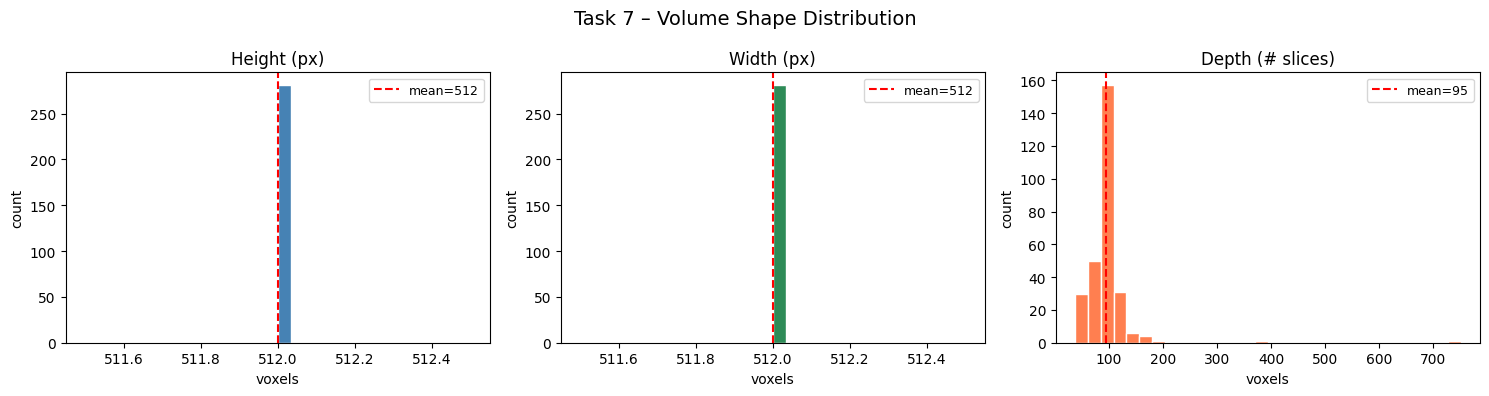

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Task 7 – Volume Shape Distribution", fontsize=14)

for ax, (dim, label, color) in enumerate(zip(
        [shapes_t7[:, 0], shapes_t7[:, 1], shapes_t7[:, 2]],
        ["Height (px)", "Width (px)", "Depth (# slices)"],
        ["steelblue", "seagreen", "coral"])):
    axes[ax].hist(dim, bins=30, color=color, edgecolor="white")
    axes[ax].set_title(label)
    axes[ax].set_xlabel("voxels")
    axes[ax].set_ylabel("count")
    axes[ax].axvline(dim.mean(), color="red", linestyle="--", label=f"mean={dim.mean():.0f}")
    axes[ax].legend(fontsize=9)

plt.tight_layout()
#plt.savefig("/home/minhc/DATN/reports/task7_shape_dist.png", dpi=120, bbox_inches="tight")
plt.show()


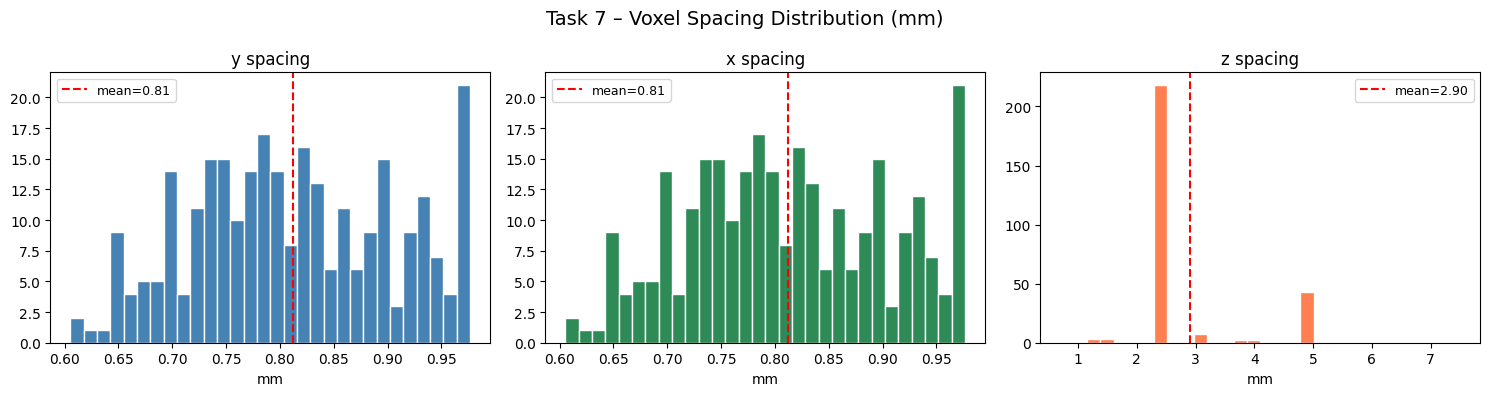

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Task 7 – Voxel Spacing Distribution (mm)", fontsize=14)

for ax, (dim, label, color) in enumerate(zip(
        [spacings_t7[:, 0], spacings_t7[:, 1], spacings_t7[:, 2]],
        ["y spacing", "x spacing", "z spacing"],
        ["steelblue", "seagreen", "coral"])):
    axes[ax].hist(dim, bins=30, color=color, edgecolor="white")
    axes[ax].set_title(label)
    axes[ax].set_xlabel("mm")
    axes[ax].axvline(dim.mean(), color="red", linestyle="--", label=f"mean={dim.mean():.2f}")
    axes[ax].legend(fontsize=9)

plt.tight_layout()
#plt.savefig("/home/minhc/DATN/reports/task7_spacing_dist.png", dpi=120, bbox_inches="tight")
plt.show()


## 4. Task 7 – Hounsfield Unit Statistics

In [13]:
# Sample 20 volumes for HU statistics (full scan takes ~15 min)
SAMPLE_N = 20
sample_files = task7_files[:SAMPLE_N]

hu_global_t7   = []   # (min, max, mean, std, p5, p95)
hu_pancreas_t7 = []   # same, only within pancreas voxels
hu_cancer_t7   = []   # only within cancer voxels

for i, img_path in enumerate(sample_files):
    lbl_path = TASK7_LBL_DIR / img_path.name
    img_data = nib.load(str(img_path)).get_fdata(dtype=np.float32)
    lbl_data = nib.load(str(lbl_path)).get_fdata(dtype=np.float32)
    
    hu_global_t7.append([
        img_data.min(), img_data.max(), img_data.mean(), img_data.std(),
        np.percentile(img_data, 5), np.percentile(img_data, 95)
    ])
    
    panc = img_data[lbl_data >= 1]   # pancreas + cancer
    if panc.size > 0:
        hu_pancreas_t7.append([
            panc.min(), panc.max(), panc.mean(), panc.std(),
            np.percentile(panc, 5), np.percentile(panc, 95)
        ])
    
    canc = img_data[lbl_data == 2]   # cancer only
    if canc.size > 0:
        hu_cancer_t7.append([
            canc.min(), canc.max(), canc.mean(), canc.std(),
            np.percentile(canc, 5), np.percentile(canc, 95)
        ])
    
    print(f"  [{i+1}/{SAMPLE_N}] {img_path.name}", end="\r")

hu_global_t7   = np.array(hu_global_t7)
hu_pancreas_t7 = np.array(hu_pancreas_t7)
hu_cancer_t7   = np.array(hu_cancer_t7)

labels_stat = ["min", "max", "mean", "std", "p5", "p95"]
print("\n── Global HU (all voxels) ──")
for j, lbl in enumerate(labels_stat):
    v = hu_global_t7[:, j]
    print(f"  {lbl:6s}: mean={v.mean():.1f}  std={v.std():.1f}")

print("\n── Pancreas HU ──")
for j, lbl in enumerate(labels_stat):
    v = hu_pancreas_t7[:, j]
    print(f"  {lbl:6s}: mean={v.mean():.1f}  std={v.std():.1f}")

print("\n── Cancer HU ──")
for j, lbl in enumerate(labels_stat):
    v = hu_cancer_t7[:, j]
    print(f"  {lbl:6s}: mean={v.mean():.1f}  std={v.std():.1f}")


  [20/20] pancreas_041.nii.gz
── Global HU (all voxels) ──
  min   : mean=-1024.0  std=0.0
  max   : mean=2270.4  std=684.3
  mean  : mean=-558.1  std=62.8
  std   : mean=494.7  std=14.7
  p5    : mean=-1024.0  std=0.0
  p95   : mean=140.6  std=18.5

── Pancreas HU ──
  min   : mean=-431.8  std=296.0
  max   : mean=1608.7  std=1217.3
  mean  : mean=75.9  std=23.7
  std   : mean=98.5  std=46.1
  p5    : mean=-38.8  std=33.1
  p95   : mean=149.4  std=19.6

── Cancer HU ──
  min   : mean=-82.3  std=111.8
  max   : mean=565.5  std=810.5
  mean  : mean=83.8  std=32.9
  std   : mean=48.6  std=50.0
  p5    : mean=25.8  std=33.7
  p95   : mean=131.4  std=32.6


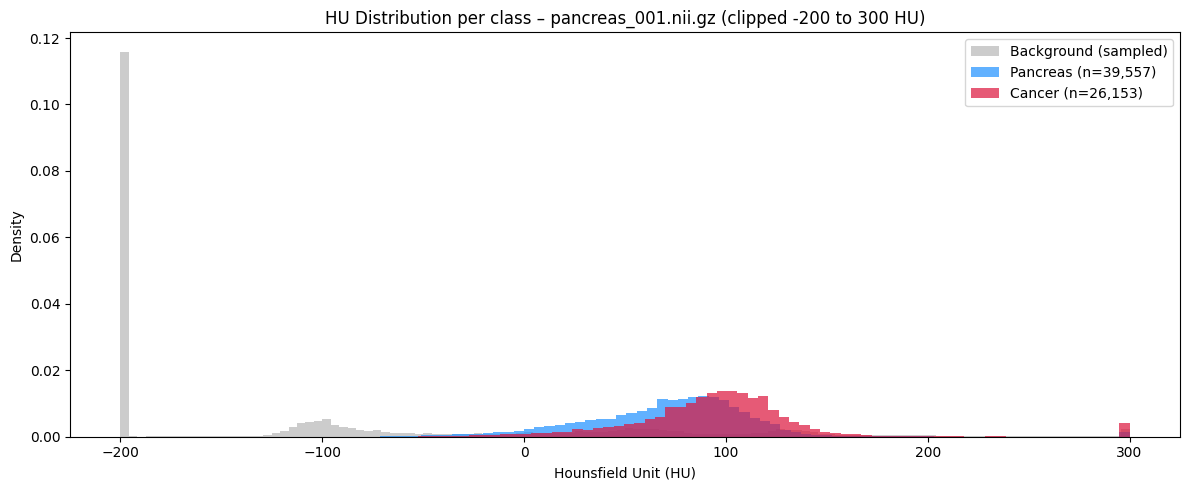

In [14]:
# HU distribution comparison: background vs pancreas vs cancer
img_ex = nib.load(str(task7_files[0])).get_fdata(dtype=np.float32)
lbl_ex = nib.load(str(TASK7_LBL_DIR / task7_files[0].name)).get_fdata(dtype=np.float32)

bg     = img_ex[lbl_ex == 0].ravel()
panc   = img_ex[lbl_ex == 1].ravel()
cancer = img_ex[lbl_ex == 2].ravel()

# Clip for display
bg     = np.clip(bg,    -200, 300)
panc   = np.clip(panc,  -200, 300)
cancer = np.clip(cancer,-200, 300)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(bg[::50],     bins=120, alpha=0.4, color="gray",    label=f"Background (sampled)", density=True)
ax.hist(panc,         bins=80,  alpha=0.7, color="dodgerblue", label=f"Pancreas (n={len(panc):,})", density=True)
ax.hist(cancer,       bins=80,  alpha=0.7, color="crimson",  label=f"Cancer (n={len(cancer):,})", density=True)
ax.set_title(f"HU Distribution per class – {task7_files[0].name} (clipped -200 to 300 HU)")
ax.set_xlabel("Hounsfield Unit (HU)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig("/home/minhc/DATN/reports/task7_hu_dist.png", dpi=120, bbox_inches="tight")
plt.show()


## 5. Task 7 – Class Balance Analysis

In [ ]:
# Compute label class fractions for all 281 volumes
fracs_bg_t7    = []
fracs_panc_t7  = []
fracs_cancer_t7 = []
has_cancer_t7  = []

print(f"Scanning {len(task7_files)} label volumes ...")
for i, img_path in enumerate(task7_files):
    lbl_path = TASK7_LBL_DIR / img_path.name
    lbl_data = nib.load(str(lbl_path)).get_fdata(dtype=np.float32)
    total = lbl_data.size
    fracs_bg_t7.append((lbl_data == 0).sum() / total)
    fracs_panc_t7.append((lbl_data == 1).sum() / total)
    f_cancer = (lbl_data == 2).sum() / total
    fracs_cancer_t7.append(f_cancer)
    has_cancer_t7.append(f_cancer > 0)
    if (i+1) % 50 == 0:
        print(f"  {i+1}/{len(task7_files)}")

fracs_bg_t7     = np.array(fracs_bg_t7)
fracs_panc_t7   = np.array(fracs_panc_t7)
fracs_cancer_t7 = np.array(fracs_cancer_t7)
has_cancer_t7   = np.array(has_cancer_t7)

print(f"\nVolumes with cancer label: {has_cancer_t7.sum()} / {len(task7_files)}")
print(f"\nClass fraction statistics:")
for cls, arr in [("Background (0)", fracs_bg_t7),
                  ("Pancreas (1)",   fracs_panc_t7),
                  ("Cancer (2)",     fracs_cancer_t7)]:
    print(f"  {cls:20s}: mean={arr.mean()*100:.3f}%  "
          f"std={arr.std()*100:.3f}%  "
          f"min={arr.min()*100:.3f}%  max={arr.max()*100:.3f}%")


Scanning 281 label volumes ...
  50/281
  100/281
  150/281
  200/281
  250/281


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Task 7 – Label Volume Fraction Distribution", fontsize=14)

for ax, (data, label, color) in zip(axes, [
    (fracs_panc_t7 * 100,  "Pancreas (%)", "dodgerblue"),
    (fracs_cancer_t7 * 100, "Cancer (%)",  "crimson"),
    (fracs_bg_t7 * 100,    "Background (%)","gray"),
]):
    ax.hist(data, bins=30, color=color, edgecolor="white")
    ax.set_title(label)
    ax.set_xlabel("% of total voxels")
    ax.axvline(data.mean(), color="red", linestyle="--",
               label=f"mean={data.mean():.3f}%")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("/home/minhc/DATN/reports/task7_label_balance.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. Task 7 – Sample Slice Visualization

In [ ]:
def show_sample(img_path, lbl_path, title=""):
    img = nib.load(str(img_path)).get_fdata(dtype=np.float32)
    lbl = nib.load(str(lbl_path)).get_fdata(dtype=np.float32)
    
    # Find slice with most pancreas voxels
    panc_per_slice = (lbl >= 1).sum(axis=(1, 2))
    best_z = int(panc_per_slice.argmax())
    
    img_sl = img[best_z]
    lbl_sl = lbl[best_z]
    
    # Soft-tissue window: -160 to 240 HU
    img_disp = np.clip(img_sl, -160, 240)
    img_disp = (img_disp - img_disp.min()) / (img_disp.max() - img_disp.min() + 1e-9)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"{title}  –  slice {best_z}/{img.shape[0]-1}", fontsize=12)
    
    axes[0].imshow(img_disp, cmap="gray")
    axes[0].set_title("CT (soft-tissue window)")
    axes[0].axis("off")
    
    axes[1].imshow(img_disp, cmap="gray")
    overlay_colors = np.zeros((*img_sl.shape, 4))
    overlay_colors[lbl_sl == 1] = [0, 0.5, 1, 0.5]    # blue = pancreas
    overlay_colors[lbl_sl == 2] = [1, 0.1, 0.1, 0.7]  # red  = cancer
    axes[1].imshow(overlay_colors)
    axes[1].set_title("CT + Label overlay")
    axes[1].axis("off")
    patches = [mpatches.Patch(color=(0, 0.5, 1, 0.5), label="Pancreas"),
               mpatches.Patch(color=(1, 0.1, 0.1, 0.7), label="Cancer")]
    axes[1].legend(handles=patches, loc="lower right", fontsize=9)
    
    axes[2].imshow(lbl_sl, cmap=ListedColormap(["black", "dodgerblue", "crimson"]),
                   vmin=0, vmax=2)
    axes[2].set_title("Label mask (0=bg, 1=pancreas, 2=cancer)")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.savefig(f"/home/minhc/DATN/reports/{Path(img_path).stem}_vis.png",
                dpi=100, bbox_inches="tight")
    plt.show()

# Visualise 3 samples: one with cancer, one without
cancer_files = [task7_files[i] for i, h in enumerate(has_cancer_t7) if h][:2]
no_cancer_files = [task7_files[i] for i, h in enumerate(has_cancer_t7) if not h][:1]

for p in cancer_files + no_cancer_files:
    show_sample(p, TASK7_LBL_DIR / p.name, p.stem)


## 7. TCIA Nifti – Volume Shapes & Spacing

In [ ]:
tcia_patients = sorted(TCIA_ROOT.iterdir())

shapes_tcia   = []
spacings_tcia = []

print(f"Scanning {len(tcia_patients)} TCIA patients ...")
for i, pdir in enumerate(tcia_patients):
    img_path = pdir / f"{pdir.name}_image.nifti"
    if not img_path.exists():
        continue
    img = nib.load(str(img_path))
    shapes_tcia.append(img.shape)
    spacings_tcia.append(np.abs(np.diag(img.affine)[:3]))
    if (i+1) % 20 == 0:
        print(f"  {i+1}/{len(tcia_patients)}")

shapes_tcia   = np.array(shapes_tcia)
spacings_tcia = np.array(spacings_tcia)

print("\n── Shape statistics (D, H, W) ──")
for ax, label in enumerate(["Depth (slices)", "Height", "Width"]):
    v = shapes_tcia[:, ax]
    print(f"  {label:20s}: mean={v.mean():.1f}  std={v.std():.1f}  "
          f"min={v.min()}  max={v.max()}")

print("\n── Voxel spacing statistics (mm) ──")
for ax, label in enumerate(["z (axial)", "y", "x"]):
    v = spacings_tcia[:, ax]
    print(f"  {label:20s}: mean={v.mean():.3f}  std={v.std():.3f}  "
          f"min={v.min():.3f}  max={v.max():.3f}")


## 8. TCIA Nifti – HU Statistics & Class Balance

In [ ]:
SAMPLE_N_TCIA = 20
sample_tcia = tcia_patients[:SAMPLE_N_TCIA]

hu_global_tcia   = []
hu_pancreas_tcia = []
fracs_bg_tcia    = []
fracs_panc_tcia  = []

for i, pdir in enumerate(sample_tcia):
    img_path = pdir / f"{pdir.name}_image.nifti"
    lbl_path = pdir / f"{pdir.name}_label.nifti"
    img_data = nib.load(str(img_path)).get_fdata(dtype=np.float32)
    lbl_data = nib.load(str(lbl_path)).get_fdata(dtype=np.float32)
    
    hu_global_tcia.append([
        img_data.min(), img_data.max(), img_data.mean(), img_data.std(),
        np.percentile(img_data, 5), np.percentile(img_data, 95)
    ])
    
    panc = img_data[lbl_data >= 1]
    if panc.size > 0:
        hu_pancreas_tcia.append([
            panc.min(), panc.max(), panc.mean(), panc.std(),
            np.percentile(panc, 5), np.percentile(panc, 95)
        ])
    
    total = lbl_data.size
    fracs_bg_tcia.append((lbl_data == 0).sum() / total)
    fracs_panc_tcia.append((lbl_data >= 1).sum() / total)
    print(f"  [{i+1}/{SAMPLE_N_TCIA}] {pdir.name}", end="\r")

hu_global_tcia   = np.array(hu_global_tcia)
hu_pancreas_tcia = np.array(hu_pancreas_tcia)
fracs_panc_tcia  = np.array(fracs_panc_tcia)

labels_stat = ["min", "max", "mean", "std", "p5", "p95"]
print("\n── Global HU (TCIA) ──")
for j, lbl in enumerate(labels_stat):
    v = hu_global_tcia[:, j]
    print(f"  {lbl:6s}: mean={v.mean():.1f}")

print("\n── Pancreas HU (TCIA) ──")
for j, lbl in enumerate(labels_stat):
    v = hu_pancreas_tcia[:, j]
    print(f"  {lbl:6s}: mean={v.mean():.1f}")

print(f"\nPancreas fraction: mean={fracs_panc_tcia.mean()*100:.3f}%  "
      f"std={fracs_panc_tcia.std()*100:.3f}%")


## 9. TCIA – Sample Slice Visualization

In [ ]:
def show_tcia_sample(pdir, title=""):
    img_path = pdir / f"{pdir.name}_image.nifti"
    lbl_path = pdir / f"{pdir.name}_label.nifti"
    img = nib.load(str(img_path)).get_fdata(dtype=np.float32)
    lbl = nib.load(str(lbl_path)).get_fdata(dtype=np.float32)
    
    panc_per_slice = (lbl >= 1).sum(axis=(1, 2))
    best_z = int(panc_per_slice.argmax())
    
    img_sl  = img[best_z]
    lbl_sl  = lbl[best_z]
    img_disp = np.clip(img_sl, -160, 240)
    img_disp = (img_disp - img_disp.min()) / (img_disp.max() - img_disp.min() + 1e-9)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"{title}  –  slice {best_z}/{img.shape[0]-1}", fontsize=12)
    
    axes[0].imshow(img_disp, cmap="gray")
    axes[0].set_title("CT (soft-tissue window)")
    axes[0].axis("off")
    
    axes[1].imshow(img_disp, cmap="gray")
    overlay = np.zeros((*img_sl.shape, 4))
    overlay[lbl_sl >= 1] = [0, 0.5, 1, 0.5]
    axes[1].imshow(overlay)
    axes[1].set_title("CT + Pancreas overlay")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.savefig(f"/home/minhc/DATN/reports/tcia_{pdir.name}_vis.png",
                dpi=100, bbox_inches="tight")
    plt.show()

for pdir in tcia_patients[:3]:
    show_tcia_sample(pdir, pdir.name)


## 10. Dataset Comparison – Task 7 vs TCIA

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Dataset Comparison: Task 7 (Decathlon) vs TCIA", fontsize=14)

# (a) Depth distribution
axes[0, 0].hist(shapes_t7[:, 0],   bins=25, alpha=0.7, color="steelblue", label="Task 7 (n=281)")
axes[0, 0].hist(shapes_tcia[:, 0], bins=25, alpha=0.7, color="darkorange", label="TCIA (n=80)")
axes[0, 0].set_title("Depth (# slices)");  axes[0, 0].set_xlabel("slices")
axes[0, 0].legend()

# (b) z-spacing distribution
axes[0, 1].hist(spacings_t7[:, 0],   bins=20, alpha=0.7, color="steelblue", label="Task 7")
axes[0, 1].hist(spacings_tcia[:, 0], bins=20, alpha=0.7, color="darkorange", label="TCIA")
axes[0, 1].set_title("z-spacing (mm)");  axes[0, 1].set_xlabel("mm")
axes[0, 1].legend()

# (c) xy spacing
axes[1, 0].hist(spacings_t7[:, 1],   bins=20, alpha=0.7, color="steelblue", label="Task 7 y")
axes[1, 0].hist(spacings_tcia[:, 1], bins=20, alpha=0.7, color="darkorange", label="TCIA y")
axes[1, 0].set_title("y-spacing (mm)");  axes[1, 0].set_xlabel("mm")
axes[1, 0].legend()

# (d) Pancreas HU mean
axes[1, 1].hist(hu_pancreas_t7[:, 2],   bins=12, alpha=0.7, color="steelblue", label="Task 7 pancreas mean HU")
axes[1, 1].hist(hu_pancreas_tcia[:, 2], bins=12, alpha=0.7, color="darkorange", label="TCIA pancreas mean HU")
axes[1, 1].set_title("Pancreas mean HU");  axes[1, 1].set_xlabel("HU")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("/home/minhc/DATN/reports/dataset_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


## 11. Write Markdown Report